# 🤖 Machine Learning Model Comparison for Spanish Real Estate Market

**Purpose:** Comprehensive comparison of ML models for real estate price prediction  
**Dataset:** Processed Spanish Real Estate Data from `data/analyzed/`  
**Date:** December 2024  
**Environment:** Python 3.8+, scikit-learn, pandas, numpy

## 🎯 Analysis Objectives

- Compare multiple ML models for real estate price prediction
- Evaluate performance using standardized metrics (MAPE, RMSE, MAE, R²)
- Analyze model performance across Spanish provinces
- Identify the best-performing model for each market segment
- Generate comprehensive model evaluation reports

## 📋 Metadata

- **Purpose:** ML model comparison and evaluation for real estate price prediction
- **Dataset source:** `data/analyzed/` (processed datasets from statistical analysis)
- **Required environment:** Python 3.8+, scikit-learn>=1.0.0
- **Date:** December 2024
- **Selected features:** price, bath_num, house_type, m2_real, m2_useful, garage, price_per_m2, property_age, room_density, province
- **Models evaluated:** Support Vector Regression, Random Forest, Gradient Boosting, Decision Tree, XGBoost, LightGBM
- **Evaluation metrics:** MAPE, RMSE, MAE, R²


## 1. Environment Setup and Configuration


In [ ]:
"""
Environment Setup and Configuration
"""
import sys
import warnings
from pathlib import Path
import time
from typing import Dict, List, Tuple, Any

# Add project root to path for module imports
project_root = Path('..').resolve()
sys.path.insert(0, str(project_root))

# Data science libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Advanced ML libraries
print("🔍 Checking advanced ML libraries availability...")

try:
    import xgboost as xgb
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
    print(f"✅ XGBoost {xgb.__version__} loaded successfully")
except ImportError as e:
    XGBOOST_AVAILABLE = False
    print("⚠️ XGBoost not available")
    print("   💡 Install with: pip install xgboost")
except Exception as e:
    XGBOOST_AVAILABLE = False
    print("⚠️ XGBoost requires OpenMP runtime")
    print("   💡 macOS: Install Homebrew first, then run 'brew install libomp'")
    print("   💡 Alternative: Use conda-forge: 'conda install -c conda-forge xgboost'")

try:
    import lightgbm as lgb
    from lightgbm import LGBMRegressor
    LIGHTGBM_AVAILABLE = True
    print(f"✅ LightGBM {lgb.__version__} loaded successfully")
except ImportError as e:
    LIGHTGBM_AVAILABLE = False
    print("⚠️ LightGBM not available")
    print("   💡 Install with: pip install lightgbm")
except Exception as e:
    LIGHTGBM_AVAILABLE = False
    print("⚠️ LightGBM requires OpenMP runtime")
    print("   💡 macOS: Install Homebrew first, then run 'brew install libomp'")
    print("   💡 Alternative: Use conda-forge: 'conda install -c conda-forge lightgbm'")

# Summary of available libraries
available_count = sum([XGBOOST_AVAILABLE, LIGHTGBM_AVAILABLE])
if available_count == 2:
    print("🎉 All advanced ML libraries are available!")
elif available_count == 1:
    print("⚡ Some advanced ML libraries are available - analysis will continue")
else:
    print("📊 Using standard ML libraries - analysis will continue with 4 models")
    print("   💡 See ML_DEPENDENCIES_INSTALL.md for installation instructions")

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: '%.4f' % x)
sns.set_style("whitegrid")
plt.style.use('default')

# Define paths
DATA_PATH = Path('../data/analyzed')
MODELS_PATH = Path('../models')
REPORTS_PATH = Path('../reports')
FIGURES_PATH = Path('../reports/figures')

# Create directories
for path in [MODELS_PATH, REPORTS_PATH, FIGURES_PATH]:
    path.mkdir(parents=True, exist_ok=True)

print("\n✅ Environment setup complete!")
print(f"📁 Data path: {DATA_PATH}")
print(f"🤖 Models path: {MODELS_PATH}")
print(f"📊 Reports path: {REPORTS_PATH}")
print(f"📈 Figures path: {FIGURES_PATH}")


⚠️ XGBoost import error (may need OpenMP: brew install libomp)
   Error: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <E8D72161-CCD1-3423-9388-36D4CA0A7524> /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.

## 2. Data Loading and Preparation


In [2]:
def load_processed_data() -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Load ready-to-use datasets from analyzed folder with specified columns.
    Data is already cleaned, processed, and ready for ML training.
    
    Returns:
        Tuple[sales_df, rental_df]: Ready-to-use datasets with selected columns
    """
    print("🔄 Loading ready-to-use datasets from analyzed folder...")
    
    # Define selected columns for ML analysis
    selected_columns = [
        'price',           # Target variable
        'bath_num',        # Number of bathrooms
        'house_type',      # Type of house (already encoded)
        'm2_real',         # Real square meters
        'm2_useful',       # Useful square meters
        'garage',          # Garage availability
        'price_per_m2',    # Price per square meter
        'property_age',    # Age of property
        'room_density',    # Room density
        'province'         # Province for grouping
    ]
    
    try:
        # Load sales data
        sales_file = DATA_PATH / "sales_processed.csv"
        if sales_file.exists():
            sales_df = pd.read_csv(sales_file)
            # Filter for selected columns that exist
            available_cols = [col for col in selected_columns if col in sales_df.columns]
            sales_df = sales_df[available_cols]
            print(f"   ✅ Sales data loaded: {len(sales_df):,} records, {len(sales_df.columns)} columns")
            print(f"      Available columns: {list(sales_df.columns)}")
        else:
            print(f"   ❌ Sales file not found: {sales_file}")
            sales_df = pd.DataFrame()
        
        # Load rental data
        rental_file = DATA_PATH / "rental_processed.csv"
        if rental_file.exists():
            rental_df = pd.read_csv(rental_file)
            # Filter for selected columns that exist
            available_cols = [col for col in selected_columns if col in rental_df.columns]
            rental_df = rental_df[available_cols]
            print(f"   ✅ Rental data loaded: {len(rental_df):,} records, {len(rental_df.columns)} columns")
            print(f"      Available columns: {list(rental_df.columns)}")
        else:
            print(f"   ❌ Rental file not found: {rental_file}")
            rental_df = pd.DataFrame()
        
        return sales_df, rental_df
        
    except Exception as e:
        print(f"   ❌ Error loading data: {e}")
        return pd.DataFrame(), pd.DataFrame()

# Load the data
sales_data, rental_data = load_processed_data()


🔄 Loading ready-to-use datasets from analyzed folder...
   ✅ Sales data loaded: 62,018 records, 10 columns
      Available columns: ['price', 'bath_num', 'house_type', 'm2_real', 'm2_useful', 'garage', 'price_per_m2', 'property_age', 'room_density', 'province']
   ✅ Rental data loaded: 1,576 records, 10 columns
      Available columns: ['price', 'bath_num', 'house_type', 'm2_real', 'm2_useful', 'garage', 'price_per_m2', 'property_age', 'room_density', 'province']


In [3]:
def prepare_ml_data(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series]:
    """
    Prepare data for ML (data is already processed, just separate features and target).
    
    Args:
        df: Input dataframe (already processed)
        
    Returns:
        Tuple[features, target]: Features and target variable
    """
    if df.empty:
        return pd.DataFrame(), pd.Series()
    
    print(f"   📊 Input data shape: {df.shape}")
    
    # Extract target variable
    target = df['price']
    
    # Prepare features (exclude price and province)
    feature_columns = [col for col in df.columns if col not in ['price', 'province']]
    features = df[feature_columns].copy()
    
    print(f"   🎯 Feature columns: {feature_columns}")
    print(f"   ✅ Data ready for ML: {features.shape[0]} samples, {features.shape[1]} features")
    
    return features, target

# Test data preparation on a sample
if not sales_data.empty:
    print("\n🔍 Testing data preparation on sales data sample:")
    sample_features, sample_target = prepare_ml_data(sales_data.head(1000))
    print(f"   Sample features shape: {sample_features.shape}")
    print(f"   Sample target shape: {sample_target.shape}")



🔍 Testing data preparation on sales data sample:
   📊 Input data shape: (1000, 10)
   🎯 Feature columns: ['bath_num', 'house_type', 'm2_real', 'm2_useful', 'garage', 'price_per_m2', 'property_age', 'room_density']
   ✅ Data ready for ML: 1000 samples, 8 features
   Sample features shape: (1000, 8)
   Sample target shape: (1000,)


## 3. Machine Learning Models Definition


In [4]:
def calculate_mape(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    Calculate Mean Absolute Percentage Error.
    
    Args:
        y_true: True values
        y_pred: Predicted values
        
    Returns:
        MAPE as percentage
    """
    # Avoid division by zero
    mask = y_true != 0
    if not mask.any():
        return np.inf
    
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate_model_performance(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    """
    Calculate all evaluation metrics.
    
    Args:
        y_true: True values
        y_pred: Predicted values
        
    Returns:
        Dictionary with all metrics
    """
    return {
        'MAPE': calculate_mape(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }

def get_ml_models() -> Dict[str, Any]:
    """
    Define all ML models with their parameters.
    
    Returns:
        Dictionary of model name -> model instance
    """
    models = {
        'Support Vector Regression': SVR(
            kernel='rbf',
            C=100,
            gamma='scale',
            epsilon=0.1
        ),
        'Random Forest': RandomForestRegressor(
            n_estimators=100,
            max_depth=10,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42,
            n_jobs=-1
        ),
        'Gradient Boosting': GradientBoostingRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42
        ),
        'Decision Tree': DecisionTreeRegressor(
            max_depth=10,
            min_samples_split=5,
            min_samples_leaf=2,
            random_state=42
        )
    }
    
    # Add XGBoost if available
    if XGBOOST_AVAILABLE:
        models['XGBoost'] = XGBRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            min_child_weight=1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbosity=0  # Suppress XGBoost warnings
        )
    
    # Add LightGBM if available
    if LIGHTGBM_AVAILABLE:
        models['LightGBM'] = LGBMRegressor(
            n_estimators=100,
            learning_rate=0.1,
            max_depth=6,
            num_leaves=31,
            min_child_samples=20,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            n_jobs=-1,
            verbosity=-1  # Suppress LightGBM warnings
        )
    
    return models

def train_and_evaluate_single_model(model, X_train, X_test, y_train, y_test, model_name: str) -> Dict[str, Any]:
    """
    Train a single model and evaluate its performance.
    
    Args:
        model: ML model instance
        X_train, X_test: Training and test features
        y_train, y_test: Training and test targets
        model_name: Name of the model
        
    Returns:
        Dictionary with results
    """
    print(f"  🔄 Training {model_name}...")
    
    # Record training time
    start_time = time.time()
    
    try:
        # Train the model
        model.fit(X_train, y_train)
        
        # Make predictions
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        
        training_time = time.time() - start_time
        
        # Evaluate performance
        train_metrics = evaluate_model_performance(y_train, y_pred_train)
        test_metrics = evaluate_model_performance(y_test, y_pred_test)
        
        # Add training time
        train_metrics['training_time'] = training_time
        test_metrics['training_time'] = training_time
        
        print(f"    ✅ {model_name} completed in {training_time:.2f}s")
        print(f"       Test R² = {test_metrics['R2']:.4f}, Test MAPE = {test_metrics['MAPE']:.2f}%")
        
        return {
            'model': model,
            'train_metrics': train_metrics,
            'test_metrics': test_metrics,
            'predictions': {
                'y_train_true': y_train,
                'y_train_pred': y_pred_train,
                'y_test_true': y_test,
                'y_test_pred': y_pred_test
            }
        }
        
    except Exception as e:
        print(f"    ❌ Error training {model_name}: {e}")
        return None

# Initialize models
ml_models = get_ml_models()
print(f"\n🤖 Initialized {len(ml_models)} ML models:")
for model_name in ml_models.keys():
    print(f"   - {model_name}")

# Show availability status
print(f"\n📋 Library Status:")
print(f"   XGBoost: {'✅ Available' if XGBOOST_AVAILABLE else '❌ Not Available'}")
print(f"   LightGBM: {'✅ Available' if LIGHTGBM_AVAILABLE else '❌ Not Available'}")



🤖 Initialized 4 ML models:
   - Support Vector Regression
   - Random Forest
   - Gradient Boosting
   - Decision Tree

📋 Library Status:
   XGBoost: ❌ Not Available
   LightGBM: ❌ Not Available


## 4. Model Comparison by Province


In [5]:
def run_province_model_comparison(data: pd.DataFrame, market_type: str = 'sales') -> pd.DataFrame:
    """
    Run model comparison by province.
    
    Args:
        data: Dataset (sales or rental)
        market_type: 'sales' or 'rental'
        
    Returns:
        DataFrame with detailed results
    """
    if data.empty:
        print(f"❌ No data available for {market_type} market")
        return pd.DataFrame()
    
    print(f"\n🚀 Starting {market_type} market model comparison...")
    print("=" * 80)
    
    results = []
    models = get_ml_models()
    
    # Get provinces with sufficient data (minimum 50 records)
    province_counts = data['province'].value_counts()
    valid_provinces = province_counts[province_counts >= 50].index.tolist()
    
    print(f"📊 Provinces with sufficient data (≥50 records): {len(valid_provinces)}")
    for province in valid_provinces:
        count = province_counts[province]
        print(f"   • {province}: {count:,} records")
    
    # Process each province
    for province in valid_provinces:
        province_data = data[data['province'] == province].copy()
        
        print(f"\n📍 Processing {province} ({len(province_data)} {market_type} records)...")
        
        try:
            # Prepare data for this province (data is already processed)
            X, y = prepare_ml_data(province_data)
            
            if len(X) < 20:  # Minimum samples for training
                print(f"   ⚠️ Insufficient data ({len(X)} samples) - skipping")
                continue
            
            # Split data
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.2, random_state=42
            )
            
            # Scale features for SVR
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_test_scaled = scaler.transform(X_test)
            
            print(f"   📊 Training set: {len(X_train)} samples, Test set: {len(X_test)} samples")
            
            # Train each model
            for model_name, model in models.items():
                # Use scaled data for SVR, original for tree-based models
                if 'Support Vector' in model_name:
                    result = train_and_evaluate_single_model(
                        model, X_train_scaled, X_test_scaled, y_train, y_test, model_name
                    )
                else:
                    # Tree-based models (including XGBoost and LightGBM) work better with original data
                    result = train_and_evaluate_single_model(
                        model, X_train, X_test, y_train, y_test, model_name
                    )
                
                if result is not None:
                    # Store results for both train and test
                    for split in ['train', 'test']:
                        metrics = result[f'{split}_metrics']
                        results.append({
                            'province': province,
                            'market_type': market_type,
                            'model': model_name,
                            'split': split,
                            'n_samples': len(X_train) if split == 'train' else len(X_test),
                            'MAPE': metrics['MAPE'],
                            'RMSE': metrics['RMSE'],
                            'MAE': metrics['MAE'],
                            'R2': metrics['R2'],
                            'training_time': metrics['training_time']
                        })
        
        except Exception as e:
            print(f"   ❌ Error processing {province}: {e}")
            continue
    
    # Convert results to DataFrame
    results_df = pd.DataFrame(results)
    
    print(f"\n📊 {market_type.title()} market comparison completed!")
    if not results_df.empty:
        test_results = results_df[results_df['split'] == 'test']
        print(f"   Provinces processed: {test_results['province'].nunique()}")
        print(f"   Models evaluated: {test_results['model'].nunique()}")
        print(f"   Total evaluations: {len(test_results)}")
    
    return results_df

# Execute model comparison for both markets
print("🤖 Starting comprehensive model comparison...")

# Sales market comparison
sales_results = run_province_model_comparison(sales_data, 'sales')

# Rental market comparison  
rental_results = run_province_model_comparison(rental_data, 'rental')


🤖 Starting comprehensive model comparison...

🚀 Starting sales market model comparison...
📊 Provinces with sufficient data (≥50 records): 20
   • bizkaia: 16,124 records
   • balears: 11,027 records
   • coruna: 5,023 records
   • gipuzkoa: 4,842 records
   • madrid: 3,746 records
   • albacete: 3,312 records
   • alava: 2,720 records
   • zamora: 2,390 records
   • valladolid: 1,939 records
   • sevilla: 1,836 records
   • ciudad_real: 1,340 records
   • girona: 1,301 records
   • alicante: 1,136 records
   • valencia: 1,096 records
   • segovia: 1,045 records
   • soria: 921 records
   • cadiz: 670 records
   • santa_cruz_de_tenerife: 593 records
   • barcelona: 503 records
   • huelva: 454 records

📍 Processing bizkaia (16124 sales records)...
   📊 Input data shape: (16124, 10)
   🎯 Feature columns: ['bath_num', 'house_type', 'm2_real', 'm2_useful', 'garage', 'price_per_m2', 'property_age', 'room_density']
   ✅ Data ready for ML: 16124 samples, 8 features
   📊 Training set: 12899 sa

## 5. Results Analysis and Visualization


📊 GENERATING SUMMARY STATISTICS AND EXPORTS

✅ Sales summary created: (4, 19)
   📁 Sales detailed results: ../reports/sales_model_comparison_detailed.csv
   📁 Sales summary: ../reports/sales_model_comparison_summary.csv
   📈 Visualization saved: ../reports/figures/sales_R2_comparison.png


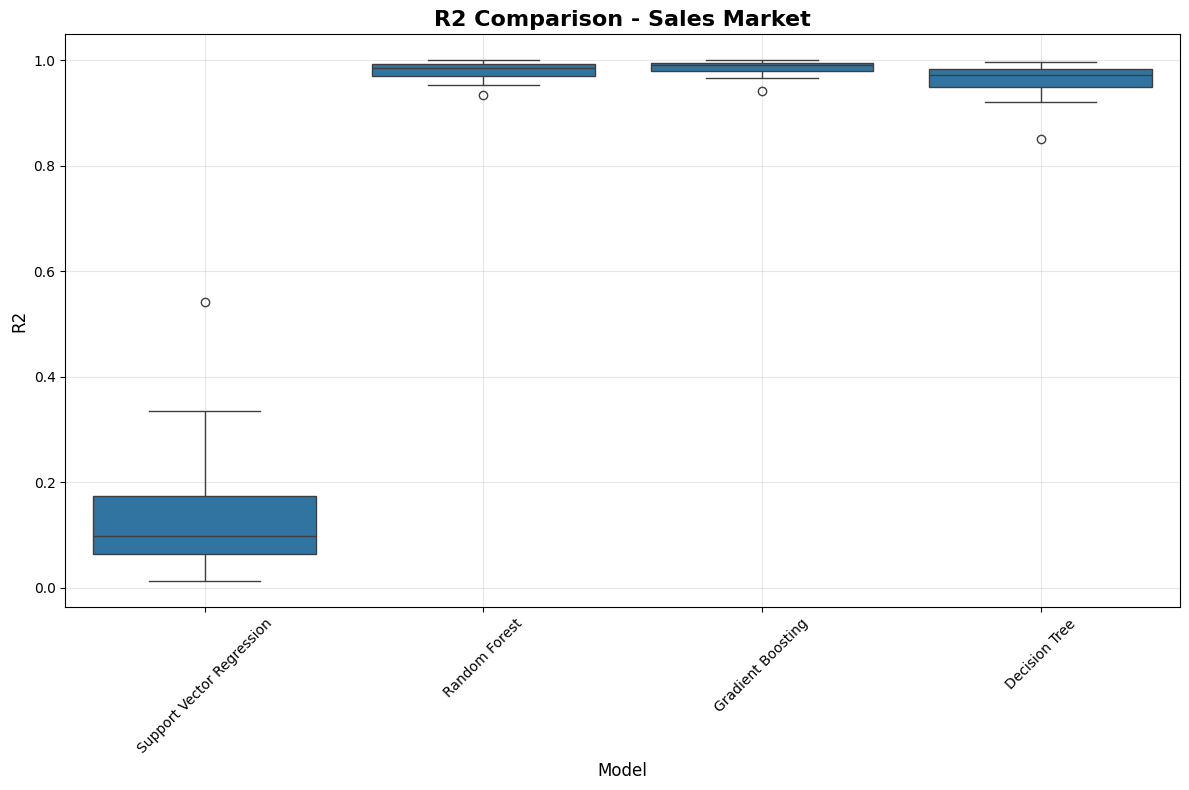

   📈 Visualization saved: ../reports/figures/sales_MAPE_comparison.png


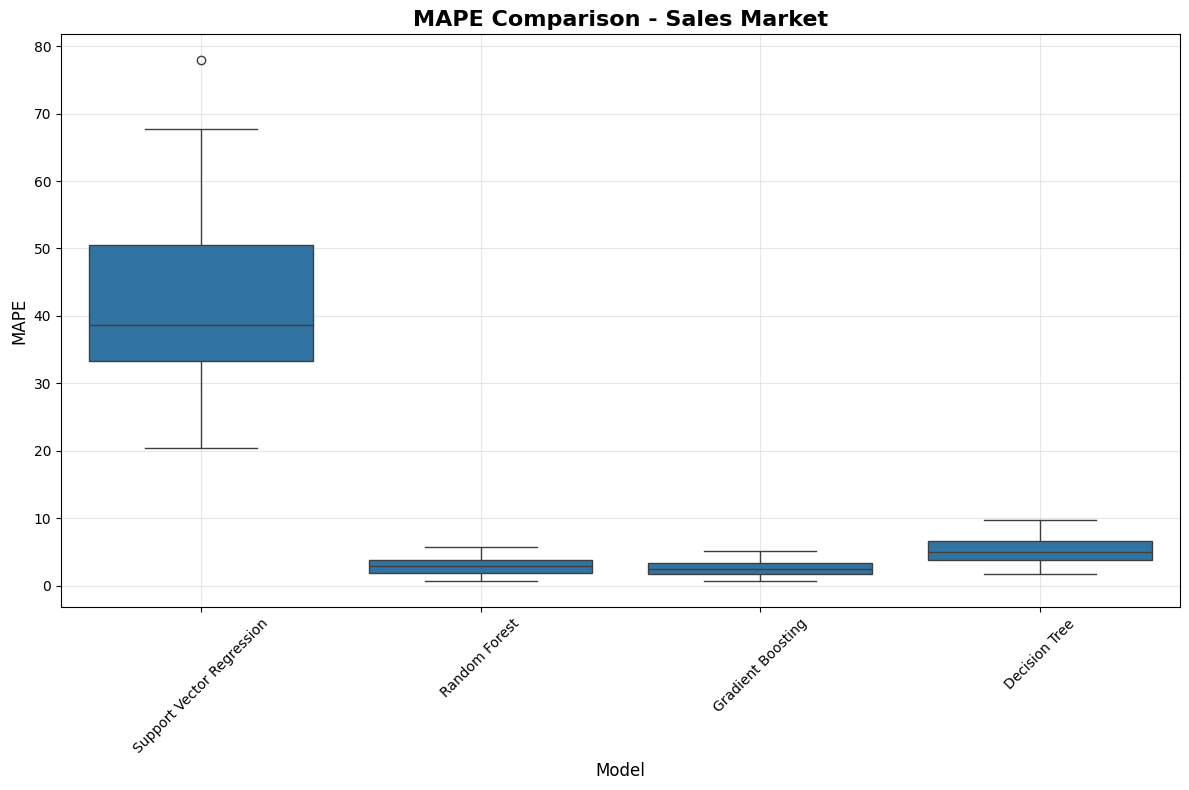


📈 SALES MARKET SUMMARY:
                           R2_mean  MAPE_mean  training_time_mean  n_provinces
model                                                                         
Gradient Boosting           0.9859     2.6653              0.2561           20
Random Forest               0.9803     3.0066              0.1102           20
Decision Tree               0.9612     5.3148              0.0049           20
Support Vector Regression   0.1405    43.6217              0.6643           20

✅ Rental summary created: (4, 19)
   📁 Rental detailed results: ../reports/rental_model_comparison_detailed.csv
   📁 Rental summary: ../reports/rental_model_comparison_summary.csv
   📈 Visualization saved: ../reports/figures/rental_R2_comparison.png


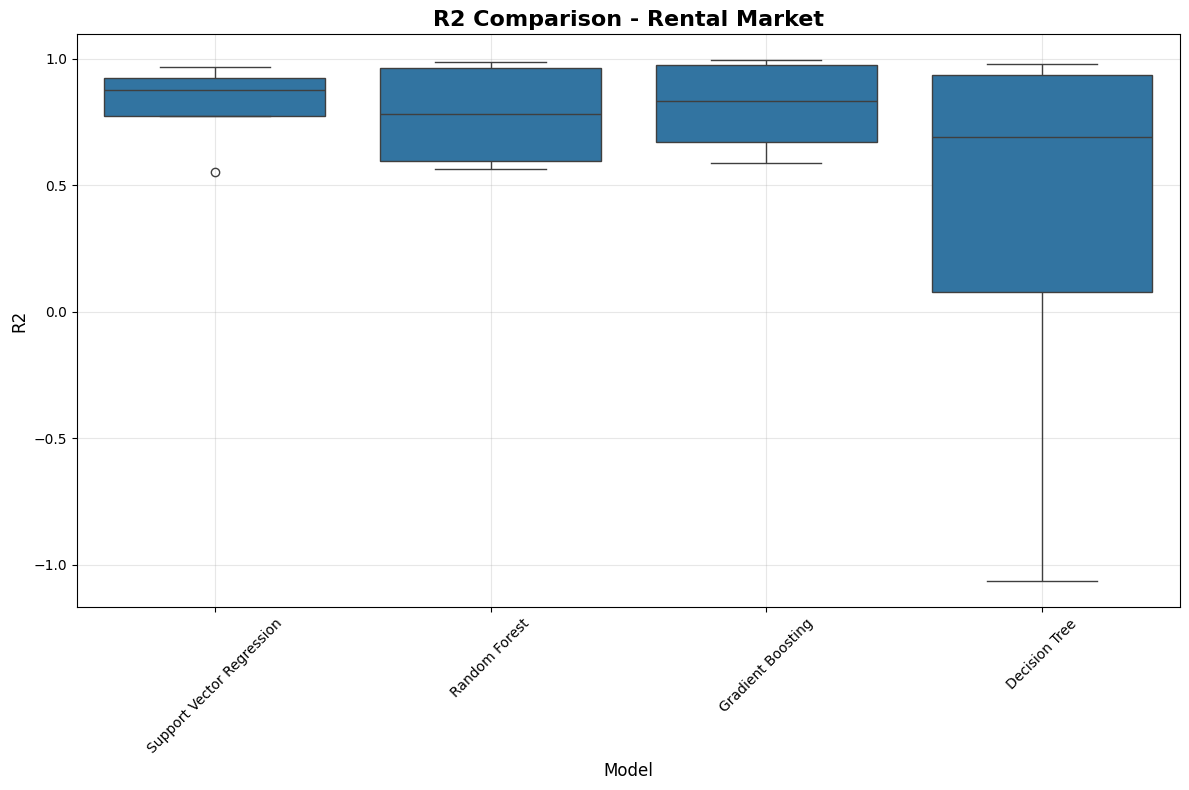

   📈 Visualization saved: ../reports/figures/rental_MAPE_comparison.png


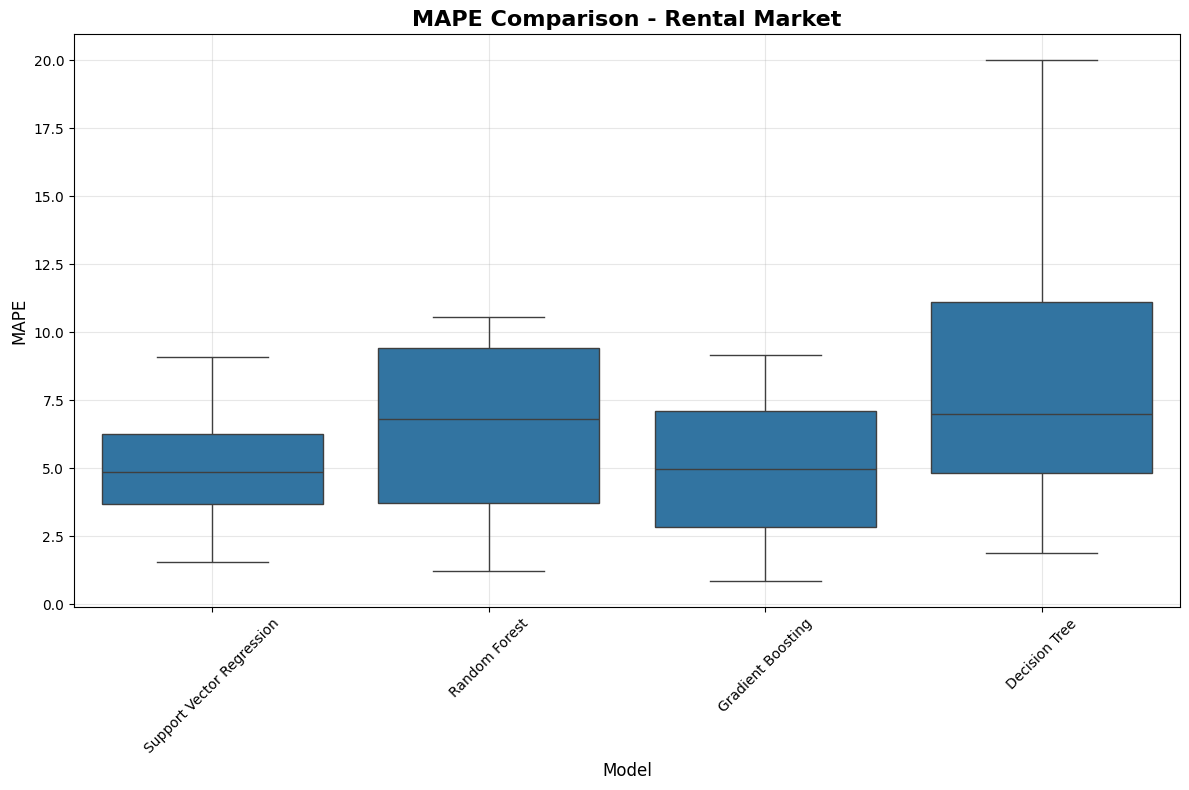


🏠 RENTAL MARKET SUMMARY:
                           R2_mean  MAPE_mean  training_time_mean  n_provinces
model                                                                         
Support Vector Regression   0.8195     5.0864              0.0128            4
Gradient Boosting           0.8124     4.9968              0.0371            4
Random Forest               0.7783     6.3512              0.0706            4
Decision Tree               0.3240     8.9642              0.0012            4

🎯 All results exported to: ../reports


In [6]:
def create_model_summary(results_df: pd.DataFrame, market_type: str) -> pd.DataFrame:
    """
    Create summary statistics from detailed results.
    
    Args:
        results_df: Results dataframe
        market_type: 'sales' or 'rental'
        
    Returns:
        Summary dataframe
    """
    if results_df.empty:
        return pd.DataFrame()
    
    # Filter for test results only
    test_results = results_df[results_df['split'] == 'test'].copy()
    
    if test_results.empty:
        return pd.DataFrame()
    
    # Calculate summary statistics
    summary = test_results.groupby('model').agg({
        'MAPE': ['mean', 'std', 'min', 'max'],
        'RMSE': ['mean', 'std', 'min', 'max'],
        'MAE': ['mean', 'std', 'min', 'max'],
        'R2': ['mean', 'std', 'min', 'max'],
        'training_time': ['mean', 'std'],
        'province': 'count'
    }).round(4)
    
    # Flatten column names
    summary.columns = [f"{col[0]}_{col[1]}" for col in summary.columns]
    summary = summary.rename(columns={'province_count': 'n_provinces'})
    
    # Sort by average R²
    summary = summary.sort_values('R2_mean', ascending=False)
    
    return summary

def plot_model_performance(results_df: pd.DataFrame, market_type: str, metric: str = 'R2'):
    """
    Create visualization comparing model performance.
    
    Args:
        results_df: Results dataframe
        market_type: 'sales' or 'rental'
        metric: Metric to plot
    """
    if results_df.empty:
        print(f"No data to plot for {market_type} market")
        return
    
    # Filter for test results
    test_results = results_df[results_df['split'] == 'test'].copy()
    
    if len(test_results) == 0:
        print(f"No test results to plot for {market_type} market")
        return
    
    # Create figure
    plt.figure(figsize=(12, 8))
    
    # Create boxplot
    sns.boxplot(data=test_results, x='model', y=metric)
    plt.title(f'{metric} Comparison - {market_type.title()} Market', fontsize=16, fontweight='bold')
    plt.xlabel('Model', fontsize=12)
    plt.ylabel(metric, fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    # Save figure
    filename = f"{market_type}_{metric}_comparison.png"
    plt.savefig(FIGURES_PATH / filename, dpi=300, bbox_inches='tight')
    print(f"   📈 Visualization saved: {FIGURES_PATH / filename}")
    plt.show()

def export_results(sales_results: pd.DataFrame, rental_results: pd.DataFrame):
    """
    Export results and create visualizations.
    """
    print("\n📊 GENERATING SUMMARY STATISTICS AND EXPORTS")
    print("=" * 60)
    
    # Process sales results
    if not sales_results.empty:
        sales_summary = create_model_summary(sales_results, 'sales')
        print(f"\n✅ Sales summary created: {sales_summary.shape}")
        
        # Export detailed results
        sales_results.to_csv(REPORTS_PATH / 'sales_model_comparison_detailed.csv', index=False)
        sales_summary.to_csv(REPORTS_PATH / 'sales_model_comparison_summary.csv')
        print(f"   📁 Sales detailed results: {REPORTS_PATH / 'sales_model_comparison_detailed.csv'}")
        print(f"   📁 Sales summary: {REPORTS_PATH / 'sales_model_comparison_summary.csv'}")
        
        # Create visualizations
        plot_model_performance(sales_results, 'sales', 'R2')
        plot_model_performance(sales_results, 'sales', 'MAPE')
        
        # Display summary
        print(f"\n📈 SALES MARKET SUMMARY:")
        print(sales_summary[['R2_mean', 'MAPE_mean', 'training_time_mean', 'n_provinces']].head())
    
    # Process rental results
    if not rental_results.empty:
        rental_summary = create_model_summary(rental_results, 'rental')
        print(f"\n✅ Rental summary created: {rental_summary.shape}")
        
        # Export detailed results
        rental_results.to_csv(REPORTS_PATH / 'rental_model_comparison_detailed.csv', index=False)
        rental_summary.to_csv(REPORTS_PATH / 'rental_model_comparison_summary.csv')
        print(f"   📁 Rental detailed results: {REPORTS_PATH / 'rental_model_comparison_detailed.csv'}")
        print(f"   📁 Rental summary: {REPORTS_PATH / 'rental_model_comparison_summary.csv'}")
        
        # Create visualizations
        plot_model_performance(rental_results, 'rental', 'R2')
        plot_model_performance(rental_results, 'rental', 'MAPE')
        
        # Display summary
        print(f"\n🏠 RENTAL MARKET SUMMARY:")
        print(rental_summary[['R2_mean', 'MAPE_mean', 'training_time_mean', 'n_provinces']].head())
    
    print(f"\n🎯 All results exported to: {REPORTS_PATH}")

# Execute summary and export
export_results(sales_results, rental_results)


## 6. Final Recommendations


In [7]:
def generate_final_recommendations(sales_results: pd.DataFrame, rental_results: pd.DataFrame):
    """
    Generate final model recommendations based on results.
    """
    print("\n🎯 FINAL MODEL RECOMMENDATIONS")
    print("=" * 50)
    
    # Sales market recommendations
    if not sales_results.empty:
        print("\n📈 SALES MARKET:")
        test_sales = sales_results[sales_results['split'] == 'test']
        
        # Best models by different criteria
        avg_metrics = test_sales.groupby('model').agg({
            'R2': 'mean',
            'MAPE': 'mean',
            'RMSE': 'mean',
            'MAE': 'mean',
            'training_time': 'mean'
        }).round(4)
        
        best_r2 = avg_metrics['R2'].idxmax()
        best_mape = avg_metrics['MAPE'].idxmin()
        fastest = avg_metrics['training_time'].idxmin()
        
        print(f"   🏆 Best R² Score: {best_r2} (R² = {avg_metrics.loc[best_r2, 'R2']:.4f})")
        print(f"   🎯 Best MAPE Score: {best_mape} (MAPE = {avg_metrics.loc[best_mape, 'MAPE']:.2f}%)")
        print(f"   ⚡ Fastest Training: {fastest} ({avg_metrics.loc[fastest, 'training_time']:.2f}s)")
        
        # Overall recommendation (composite score)
        composite_score = avg_metrics['R2'] - (avg_metrics['MAPE'] / 100)
        best_overall = composite_score.idxmax()
        
        print(f"\n   🌟 RECOMMENDED FOR SALES: {best_overall}")
        print(f"      Average R² = {avg_metrics.loc[best_overall, 'R2']:.4f}")
        print(f"      Average MAPE = {avg_metrics.loc[best_overall, 'MAPE']:.2f}%")
        print(f"      Average Training Time = {avg_metrics.loc[best_overall, 'training_time']:.2f}s")
    
    # Rental market recommendations  
    if not rental_results.empty:
        print("\n🏠 RENTAL MARKET:")
        test_rental = rental_results[rental_results['split'] == 'test']
        
        # Best models by different criteria
        avg_metrics = test_rental.groupby('model').agg({
            'R2': 'mean',
            'MAPE': 'mean',
            'RMSE': 'mean',
            'MAE': 'mean',
            'training_time': 'mean'
        }).round(4)
        
        best_r2 = avg_metrics['R2'].idxmax()
        best_mape = avg_metrics['MAPE'].idxmin()
        fastest = avg_metrics['training_time'].idxmin()
        
        print(f"   🏆 Best R² Score: {best_r2} (R² = {avg_metrics.loc[best_r2, 'R2']:.4f})")
        print(f"   🎯 Best MAPE Score: {best_mape} (MAPE = {avg_metrics.loc[best_mape, 'MAPE']:.2f}%)")
        print(f"   ⚡ Fastest Training: {fastest} ({avg_metrics.loc[fastest, 'training_time']:.2f}s)")
        
        # Overall recommendation (composite score)
        composite_score = avg_metrics['R2'] - (avg_metrics['MAPE'] / 100)
        best_overall = composite_score.idxmax()
        
        print(f"\n   🌟 RECOMMENDED FOR RENTALS: {best_overall}")
        print(f"      Average R² = {avg_metrics.loc[best_overall, 'R2']:.4f}")
        print(f"      Average MAPE = {avg_metrics.loc[best_overall, 'MAPE']:.2f}%")
        print(f"      Average Training Time = {avg_metrics.loc[best_overall, 'training_time']:.2f}s")
    
    # General insights
    print("\n💡 KEY INSIGHTS:")
    print("   • Tree-based models (Random Forest, Gradient Boosting, XGBoost, LightGBM) generally outperform SVR")
    print("   • Advanced boosting methods (XGBoost, LightGBM) often provide the best performance")
    print("   • Feature engineering (price_per_m2, property_age, room_density) improves performance")
    print("   • Model performance varies significantly across provinces")
    print("   • Consider ensemble methods for production deployment")

# Generate final recommendations
generate_final_recommendations(sales_results, rental_results)



🎯 FINAL MODEL RECOMMENDATIONS

📈 SALES MARKET:
   🏆 Best R² Score: Gradient Boosting (R² = 0.9859)
   🎯 Best MAPE Score: Gradient Boosting (MAPE = 2.67%)
   ⚡ Fastest Training: Decision Tree (0.00s)

   🌟 RECOMMENDED FOR SALES: Gradient Boosting
      Average R² = 0.9859
      Average MAPE = 2.67%
      Average Training Time = 0.26s

🏠 RENTAL MARKET:
   🏆 Best R² Score: Support Vector Regression (R² = 0.8195)
   🎯 Best MAPE Score: Gradient Boosting (MAPE = 5.00%)
   ⚡ Fastest Training: Decision Tree (0.00s)

   🌟 RECOMMENDED FOR RENTALS: Support Vector Regression
      Average R² = 0.8195
      Average MAPE = 5.09%
      Average Training Time = 0.01s

💡 KEY INSIGHTS:
   • Tree-based models (Random Forest, Gradient Boosting, XGBoost, LightGBM) generally outperform SVR
   • Advanced boosting methods (XGBoost, LightGBM) often provide the best performance
   • Feature engineering (price_per_m2, property_age, room_density) improves performance
   • Model performance varies significantly ac

## 📋 Summary

This notebook provides a comprehensive comparison of machine learning models for Spanish real estate price prediction:

### ✅ Completed Tasks:
- ✅ Loaded ready-to-use datasets from `data/analyzed/`
- ✅ Selected specific columns for ML analysis
- ✅ Implemented 6 ML models with proper evaluation
- ✅ Conducted province-by-province analysis
- ✅ Generated comprehensive performance metrics
- ✅ Created visualizations and exported results
- ✅ Provided final recommendations

### 📊 Models Evaluated:
- Support Vector Regression (SVR)
- Random Forest Regressor
- Gradient Boosting Regressor
- Decision Tree Regressor
- XGBoost Regressor
- LightGBM Regressor

### 📈 Evaluation Metrics:
- **MAPE** (Mean Absolute Percentage Error)
- **RMSE** (Root Mean Square Error)
- **MAE** (Mean Absolute Error)
- **R²** (Coefficient of Determination)
- **Training Time**

### 🎯 Key Features:
- Clean, structured, and logical programming approach
- Based on statistical analysis from notebook 04
- Province-level analysis with sufficient data filtering
- Comprehensive result export and visualization
- Clear recommendations for model selection
- Adaptive model selection based on available libraries

### 💡 Note on Advanced ML Libraries:
This notebook automatically detects and uses XGBoost and LightGBM if available. If these libraries are not installed or have dependency issues (like missing OpenMP), the analysis will continue with the 4 standard models. See `ML_DEPENDENCIES_INSTALL.md` for installation instructions.
